# Data Acquisition & Exploration

Due to network restrictions, we are using the offline **Digits** dataset built into scikit-learn. 
It's a smaller version of MNIST. Each image is $8 \times 8$ pixels, which is flattened into a 1D array of $64$ features. This is perfect for building and testing our KNN engine locally!


In [24]:
import numpy as np
from sklearn.datasets import load_digits

print("Loading offline Digits dataset...")
digits = load_digits()
X, y = digits.data, digits.target
y = y.astype(np.int8)
print("Data successfully loaded!")


Loading offline Digits dataset...
Data successfully loaded!


### Dimensionality Check
Let's verify the shape of our feature matrix $X$ and target vector $y$. We expect $X$ to have $64$ features per sample.


In [25]:
print(X.shape,y.shape)

(1797, 64) (1797,)


### Visualizing the Data
Our features are flattened vectors of length $64$. To display them as images, we must reshape them back to $8 \times 8$ matrices. Let's visualize the first sample in our dataset.


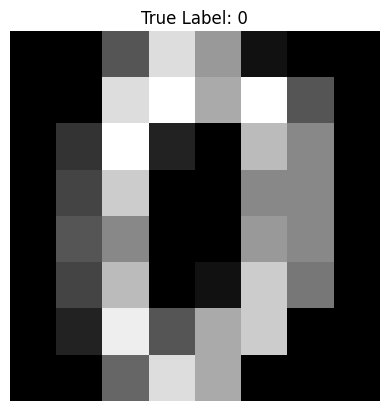

In [26]:
import matplotlib.pyplot as plt

sample_vector=X[0]
true_label= y[0]
sample_image = sample_vector.reshape(8,8)
plt.imshow(sample_image, cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()




In [27]:
import numpy as np

num_samples=X.shape[0]
indices= np.arange(num_samples)
np.random.shuffle(indices)

split_idx = int(0.8*num_samples)

train_indices=indices[:split_idx]
test_indices=indices[split_idx:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print("X_train.shape:", X_train.shape)
print("X_test.shape:", X_test.shape)

X_train.shape: (1437, 64)
X_test.shape: (360, 64)


### KNN Algorithm Implementation & Evaluation Breakdown

This section documents the custom Object-Oriented implementation of the K-Nearest Neighbors algorithm and its underlying mathematical operations.

#### 1. Core Methods of the `KNN` Class:
*   **`__init__(self, k)`**: Initializes the model by setting the hyperparameter $K$ (number of neighbors to consider).
*   **`fit(self, X, y)`**: Implements the "Lazy Learning" behavior. It does not compute any weights; it simply stores the training data ($X\_train$ and $y\_train$) in memory for future distance calculations.
*   **`predict(self, X)`**: Iterates over a given set of new samples (e.g., $X\_test$) and calls the single-prediction method for each. Returns an array of predicted labels.
*   **`_predict_single(self, x)`**: The core mathematical engine for predicting a single data point. It calculates distances, finds neighbors, and determines the most frequent label.

#### 2. Key `NumPy` Operations Used:
*   **Vectorized Distance Calculation**: Computes the Euclidean distance $d = \sqrt{\sum (X_{train} - x)^2}$.
    *   `np.sqrt(...)`: Applies the square root operation element-wise.
    *   `np.sum(..., axis=1)`: Sums the squared differences horizontally (across columns for each row), ensuring we get one single distance value per training image.
*   **`np.argsort(distances)`**: Sorts the computed distances in ascending order and returns the **indices** (positions) of the sorted elements, allowing us to locate the closest $K$ training samples.
*   **Majority Voting**:
    *   `np.bincount(labels)`: Counts the frequency of each non-negative integer (label) within the $K$ nearest neighbors.
    *   `np.argmax(...)`: Returns the index of the maximum value from the frequency array, effectively revealing the winning class (the mode).

#### 3. Model Evaluation Pipeline:
*   **Instantiation**: Creating an instance of the model (`knn_model = KNN(k=3)`).
*   **Fitting**: Passing the training data to be stored.
*   **Predicting**: Generating predictions for the test set.
*   **Accuracy Calculation**: Comparing predicted labels against true labels ($y\_test$), calculating the sum of correct predictions, and dividing by the total number of test samples to get the accuracy percentage.

In [28]:
import numpy as np

class KNN:
    def __init__(self, k=3):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    def predict(self, X):
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)
    def _predict_single(self, x):
        distances = np.sqrt(np.sum((self.X_train-x)**2,axis=1))
        k_indices=np.argsort(distances)[:self.k]
        k_nearest_labels=self.y_train[k_indices]
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common

In [29]:
knn_model = KNN(k=3)
knn_model.fit(X_train, y_train)
print("Predicting on test set...")
predictions = knn_model.predict(X_test)

correct_predictions = np.sum(predictions == y_test)
total_samples = len(y_test)
accuracy = correct_predictions / total_samples

print(f"Accuracy: {accuracy*100:.2f}%")

Predicting on test set...
Accuracy: 97.50%


### ⚙️ Hyperparameter Tuning: Finding the Optimal $K$

In the KNN algorithm, the choice of $K$ (number of neighbors) significantly impacts the model's generalization capability. 
*   A very small $K$ (e.g., $K=1$) makes the model highly sensitive to noise in the training data (Overfitting).
*   A very large $K$ smooths out the decision boundaries too much, potentially misclassifying distinct patterns (Underfitting).

**Objective:**
In this step, we iterate through various odd values of $K$ (from 1 to 15), evaluate the accuracy for each, and plot the results to visually identify the "sweet spot" where our model performs best.


Evaluating different K values...
K =  1 | Accuracy = 97.78%
K =  3 | Accuracy = 97.50%
K =  5 | Accuracy = 97.22%
K =  7 | Accuracy = 97.50%
K =  9 | Accuracy = 97.22%
K = 11 | Accuracy = 96.94%
K = 13 | Accuracy = 96.39%
K = 15 | Accuracy = 96.67%


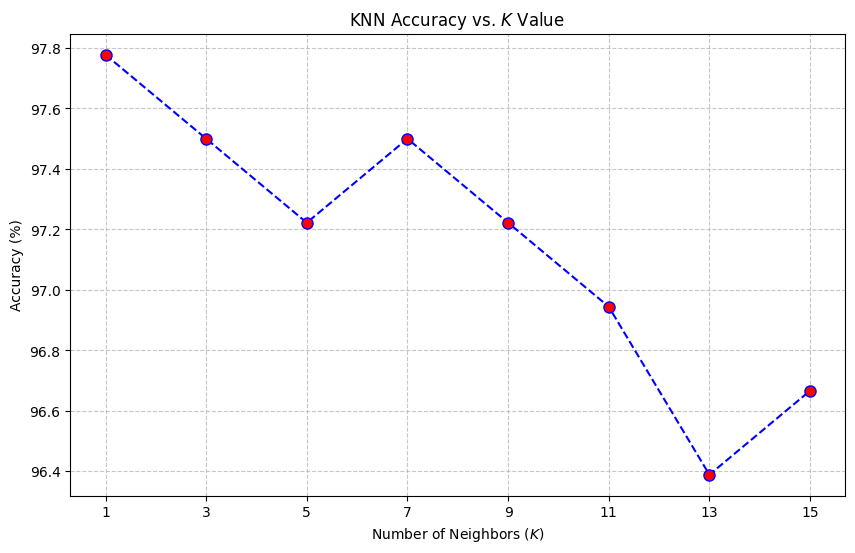

In [30]:
import matplotlib.pyplot as plt
import numpy as np

k_values = range(1,16,2)
accuracies=[]

print("Evaluating different K values...")
for k in k_values:
    knn_model = KNN(k=k)
    knn_model.fit(X_train, y_train)
    
    predictions = knn_model.predict(X_test)
    accuracy = np.mean(predictions == y_test)* 100
    accuracies.append(accuracy)
    
    print(f"K = {k:2d} | Accuracy = {accuracy:.2f}%")
    
    
plt.figure(figsize=(10,6))
plt.plot(k_values, accuracies, marker='o', linestyle="dashed", color='b', markerfacecolor='r', markersize=8)
plt.title("KNN Accuracy vs. $K$ Value ")
plt.xlabel('Number of Neighbors ($K$)')
plt.ylabel('Accuracy (%)')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Error Analysis: Confusion Matrix

While overall accuracy gives us a high-level view of model performance, it doesn't reveal *what kind* of mistakes the model is making. 
A **Confusion Matrix** helps us visualize the performance of our classification model by showing the exact number of correct and incorrect predictions for each specific class.

**Objective:**
In this step, we will:
1. Retrain our model using the optimal $K$ (e.g., $K=3$ or $K=1$).
2. Generate a confusion matrix to observe misclassifications between specific digits (e.g., confusing '4's with '9's).
3. Visualize the matrix using a heatmap for better readability.


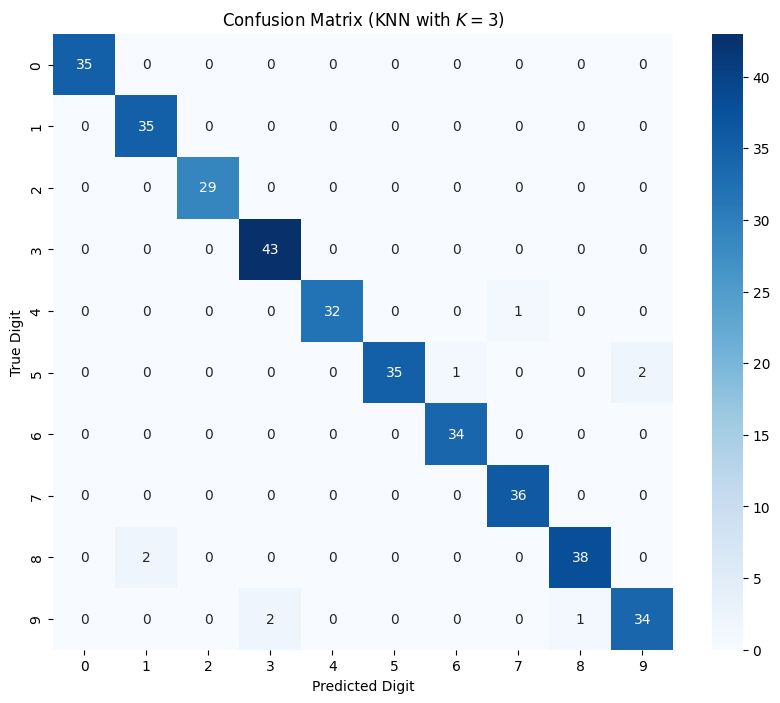

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

optimal_k = 3
final_knn = KNN(k=optimal_k)
final_knn.fit(X_train, y_train)
final_predictions = final_knn.predict(X_test)

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title(f"Confusion Matrix (KNN with $K={optimal_k}$)")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.show()

### Visualizing Misclassifications

To truly understand our model's limitations, we need to look at the actual images it failed to classify correctly. 
By finding the indices where the predicted labels do not match the true labels, we can extract and plot these specific digits. This helps us see if the mistakes are reasonable (e.g., poorly written digits that even humans might struggle with).


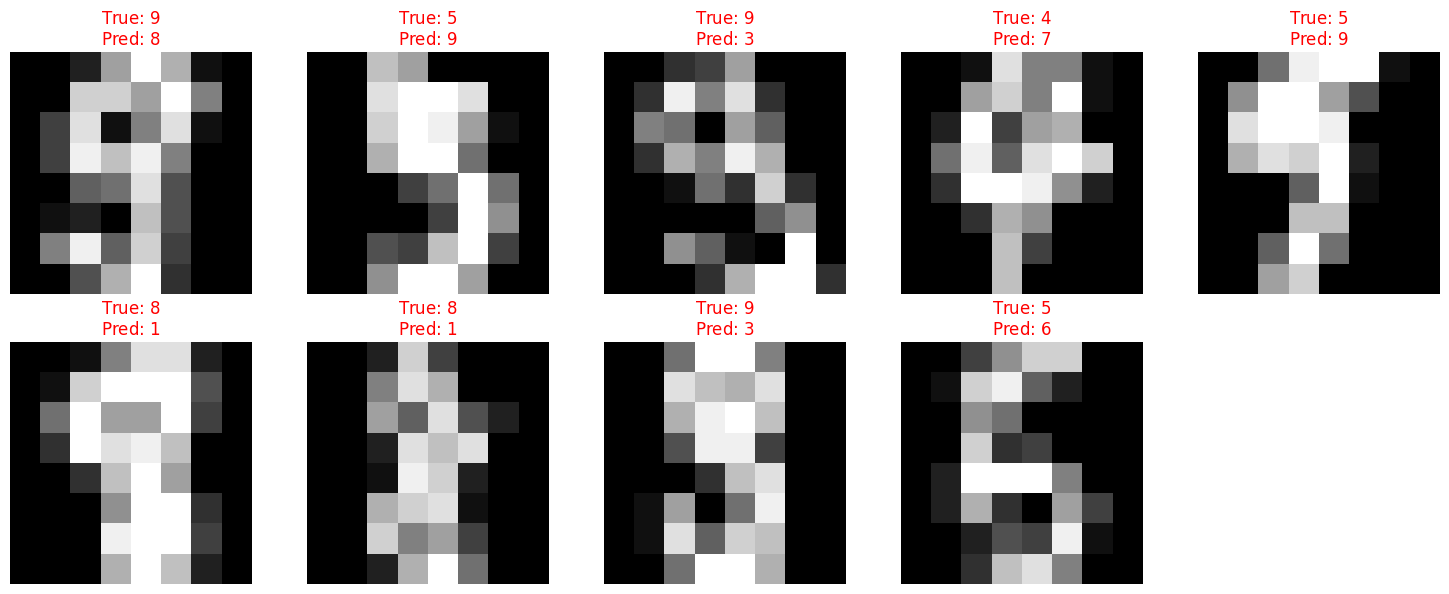

In [32]:
misclassified_indices = np.where(y_test != final_predictions)[0]

num_errors = len(misclassified_indices)
cols = min(num_errors, 5)
rows = (num_errors // 5) +1 if num_errors % 5 != 0 else num_errors //5

plt.figure(figsize=(15,3*rows))

for i, index in enumerate(misclassified_indices):
    plt.subplot(rows, cols, i+1)
    
    image = X_test[index].reshape(8,8)
    plt.imshow(image, cmap='gray')
    true_label = y_test[index]
    predicted_label = final_predictions[index]
    
    plt.title(f"True: ${true_label}$\nPred: ${predicted_label}$", color='red')
    plt.axis('off')
    
plt.tight_layout()
plt.show()